# Synthetic Data Descriptive Statistics

This notebook provides a comprehensive statistical summary of the synthetic mobile money transaction data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load Data

In [3]:
transactions = pd.read_csv('../data/transactions_calibrated.csv')
summary_extended = pd.read_csv('../data/summary_extended.csv')
user_summaries = pd.read_csv('../data/user_summaries.csv')
features = pd.read_csv('../data/features.csv')

print(f"Transactions: {transactions.shape}")
print(f"Summary Extended: {summary_extended.shape}")
print(f"User Summaries: {user_summaries.shape}")
print(f"Features: {features.shape}")

Transactions: (29711, 17)
Summary Extended: (10000, 6)
User Summaries: (10000, 6)
Features: (10000, 30)


## Data Overview

In [4]:
transactions.head()

,TRANSACTION DATE,FROM ACCT,FROM NAME,FROM NO.,TRANS. TYPE,AMOUNT,FEES,E-LEVY,BAL BEFORE,BAL AFTER,TO NO.,TO NAME,TO ACCT,is_fraud,fraud_type,hour,is_weekend
0,2024-01-01 00:01:11.706051,USER_001915,User 001915,233397431766,TRANSFER,29.439795,0.0,0.0,29.44,0.00,233313318116,Recipient_00230,ACCT_3057669,0,social_engineering,0,False
1,2024-01-01 00:02:22.478828,USER_001951,User 001951,233339294029,CASH_OUT,4.200000,0.0,0.0,194.22,190.02,233472071268,Recipient_00344,ACCT_57755684,0,social_engineering,0,False
2,2024-01-01 00:02:37.173074,USER_001614,User 001614,233539085073,CASH_OUT,17.750000,0.0,0.0,263.86,246.11,233470951558,Recipient_00327,ACCT_77071899,0,legitimate,0,False
3,2024-01-01 00:03:39.708223,USER_001938,User 001938,233505666425,TRANSFER,20.910000,0.0,0.0,93.65,72.74,233423581565,Recipient_00286,ACCT_27518971,0,sim_swap,0,False
4,2024-01-01 00:03:51.945355,USER_000110,User 000110,233215122083,DEBIT,29.180000,0.0,0.0,146.53,117.35,0,hubtel.sp,ACCT_67293833,0,legitimate,0,False


In [5]:
summary_extended.head()

,user_id,credit_archetype,loans_taken,credit_risk_label,final_credit_limit,total_transactions
0,USER_000000,responsible_borrower,2,0,78.125,21
1,USER_000001,risky_borrower,1,2,50.000,17
2,USER_000002,occasional_borrower,1,0,62.500,22
3,USER_000003,non_borrower,0,-1,0.000,17
4,USER_000004,responsible_borrower,1,0,62.500,13


## Numerical Statistics - Transactions

In [6]:
numerical_cols = ['AMOUNT', 'FEES', 'E-LEVY', 'BAL BEFORE', 'BAL AFTER', 'hour']
transactions[numerical_cols].describe()

,AMOUNT,FEES,E-LEVY,BAL BEFORE,BAL AFTER,hour
count,2.971100e+04,29711.000000,29711.000000,29711.000000,29711.000000,29711.000000
mean,2.967168e+01,0.004590,0.003321,202.262786,191.200553,13.647975
std,3.975165e+01,0.053514,0.090674,126.092348,119.900329,5.794667
min,1.776357e-15,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.710000e+00,0.000000,0.000000,107.060000,101.890000,10.000000
50%,1.464000e+01,0.000000,0.000000,178.150000,168.390000,14.000000
75%,3.305000e+01,0.000000,0.000000,270.595000,252.120000,18.000000
max,6.363700e+02,3.260000,4.430000,778.410000,737.050000,23.000000


In [7]:
for col in numerical_cols:
    data = transactions[col].dropna()
    print(f"\n{col}:")
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Std:  {data.std():.2f}")
    print(f"  CV:   {data.std() / data.mean() * 100:.1f}%" if data.mean() != 0 else "  CV:   N/A")
    print(f"  Min:  {data.min():.2f}")
    print(f"  Max:  {data.max():.2f}")


AMOUNT:
  Mean: 29.67
  Std:  39.75
  CV:   134.0%
  Min:  0.00
  Max:  636.37

FEES:
  Mean: 0.00
  Std:  0.05
  CV:   1165.9%
  Min:  0.00
  Max:  3.26

E-LEVY:
  Mean: 0.00
  Std:  0.09
  CV:   2730.3%
  Min:  0.00
  Max:  4.43

BAL BEFORE:
  Mean: 202.26
  Std:  126.09
  CV:   62.3%
  Min:  0.00
  Max:  778.41

BAL AFTER:
  Mean: 191.20
  Std:  119.90
  CV:   62.7%
  Min:  0.00
  Max:  737.05

hour:
  Mean: 13.65
  Std:  5.79
  CV:   42.5%
  Min:  0.00
  Max:  23.00


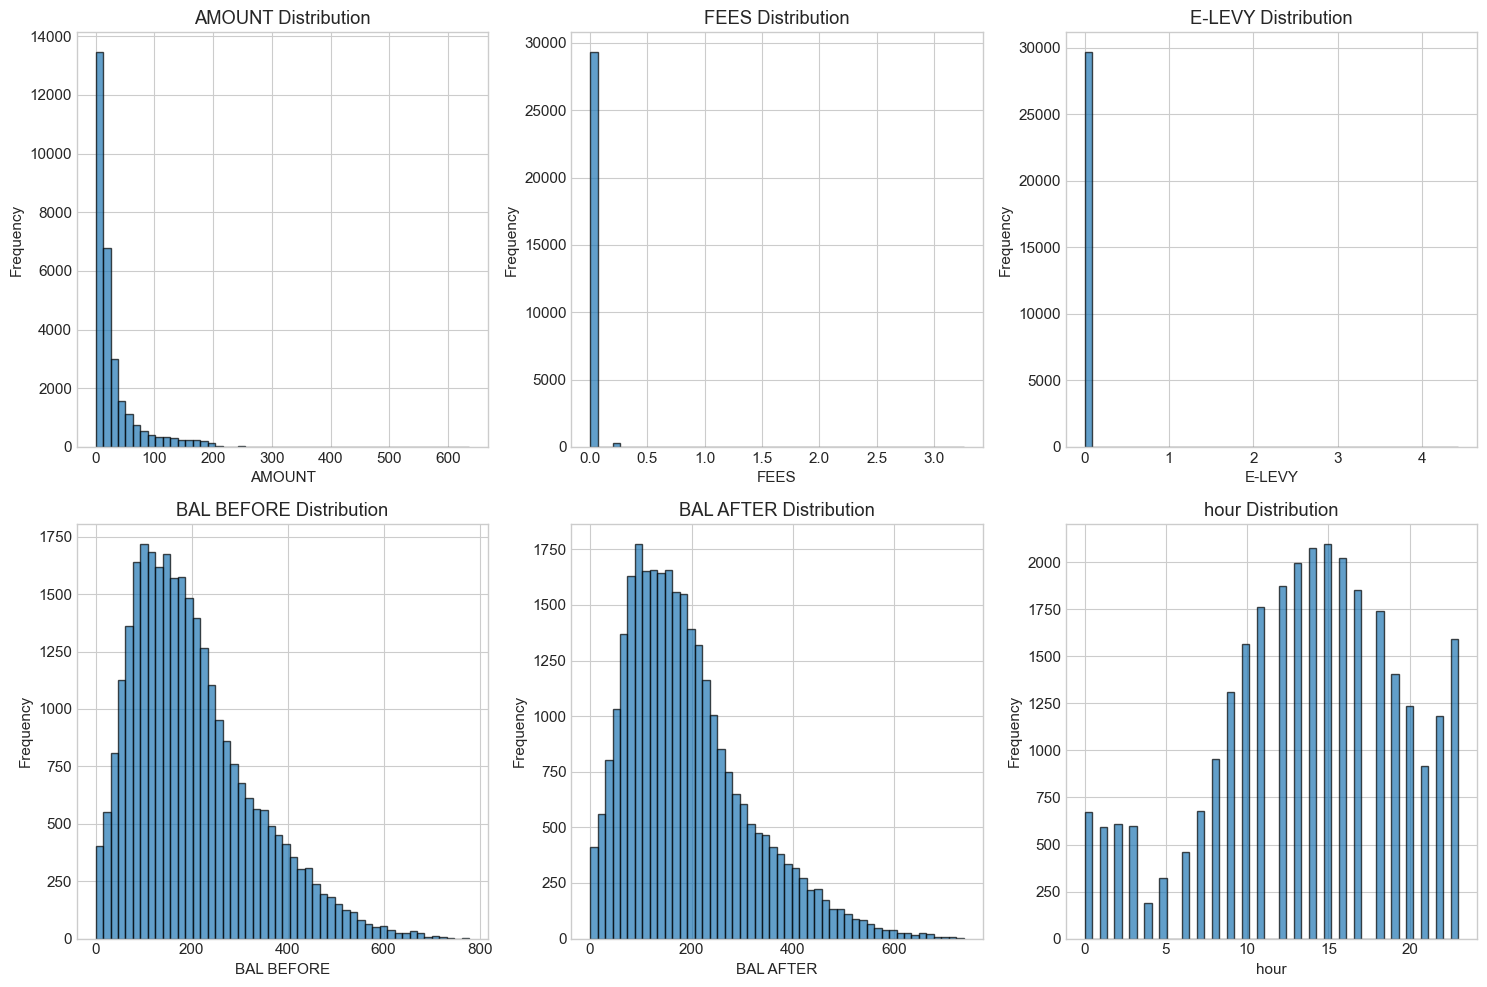

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), numerical_cols):
    transactions[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/numerical_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## Numerical Statistics - User Summary

In [10]:
summary_numerical = summary_extended.select_dtypes(include=[np.number])
summary_numerical.describe()

,loans_taken,credit_risk_label,final_credit_limit,total_transactions
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.305600,-0.079300,43.630137,17.393800
std,1.243287,0.904264,38.006152,4.843869
min,0.000000,-1.000000,0.000000,5.000000
25%,0.000000,-1.000000,0.000000,14.000000
50%,1.000000,0.000000,50.000000,17.000000
75%,2.000000,1.000000,78.125000,21.000000
max,5.000000,2.000000,122.070312,38.000000


In [11]:
num_cols = ['loans_taken', 'final_credit_limit', 'total_transactions']
for col in num_cols:
    data = summary_extended[col].dropna()
    print(f"\n{col}:")
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Std:  {data.std():.2f}")
    print(f"  CV:   {data.std() / data.mean() * 100:.1f}%" if data.mean() != 0 else "  CV:   N/A")
    print(f"  Min:  {data.min():.2f}")
    print(f"  Max:  {data.max():.2f}")


loans_taken:
  Mean: 1.31
  Std:  1.24
  CV:   95.2%
  Min:  0.00
  Max:  5.00

final_credit_limit:
  Mean: 43.63
  Std:  38.01
  CV:   87.1%
  Min:  0.00
  Max:  122.07

total_transactions:
  Mean: 17.39
  Std:  4.84
  CV:   27.8%
  Min:  5.00
  Max:  38.00


## Categorical Statistics - Transactions

In [12]:
categorical_cols = ['TRANS. TYPE', 'is_fraud', 'fraud_type']
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {transactions[col].nunique()}")
    vc = transactions[col].value_counts()
    print(f"  Distribution:")
    for val, cnt in vc.items():
        print(f"    {val}: {cnt} ({cnt/len(transactions)*100:.1f}%)")


TRANS. TYPE:
  Unique values: 6
  Distribution:
    TRANSFER: 14693 (49.5%)
    DEBIT: 7300 (24.6%)
    CASH_IN: 2209 (7.4%)
    PAYMENT: 2075 (7.0%)
    PAYMENT_SEND: 2074 (7.0%)
    CASH_OUT: 1360 (4.6%)

is_fraud:
  Unique values: 1
  Distribution:
    0: 29711 (100.0%)

fraud_type:
  Unique values: 4
  Distribution:
    legitimate: 28254 (95.1%)
    social_engineering: 573 (1.9%)
    sim_swap: 548 (1.8%)
    account_takeover: 336 (1.1%)


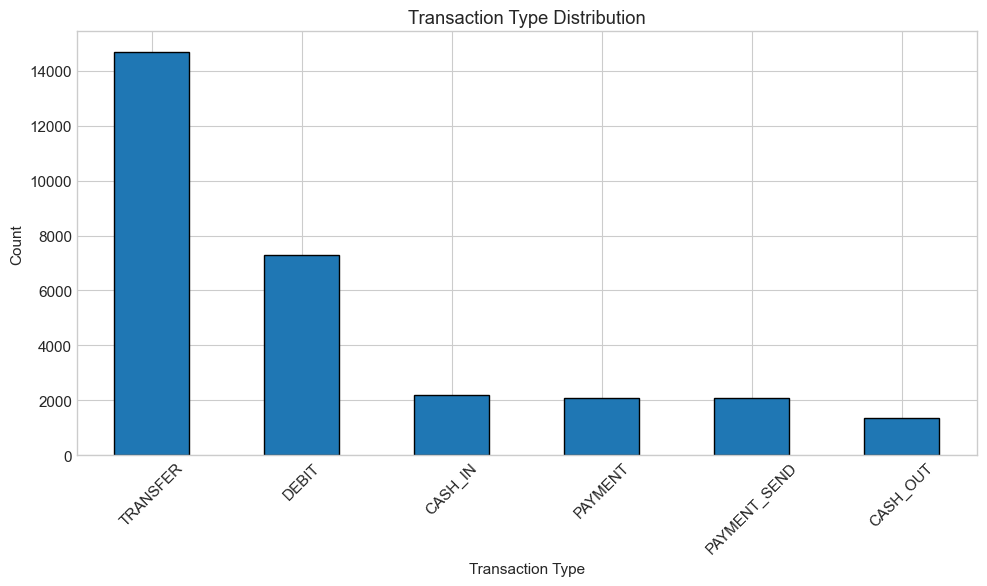

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
transactions['TRANS. TYPE'].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Transaction Type Distribution')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/transaction_types.png', dpi=100, bbox_inches='tight')
plt.show()

## Categorical Statistics - User Summary

In [15]:
cat_cols = ['credit_archetype', 'credit_risk_label']
for col in cat_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {summary_extended[col].nunique()}")
    vc = summary_extended[col].value_counts()
    print(f"  Distribution:")
    for val, cnt in vc.items():
        print(f"    {val}: {cnt} ({cnt/len(summary_extended)*100:.1f}%)")


credit_archetype:
  Unique values: 5
  Distribution:
    non_borrower: 3951 (39.5%)
    responsible_borrower: 3511 (35.1%)
    occasional_borrower: 1504 (15.0%)
    risky_borrower: 824 (8.2%)
    defaulter: 210 (2.1%)

credit_risk_label:
  Unique values: 4
  Distribution:
    -1: 3951 (39.5%)
    0: 3456 (34.6%)
    1: 2028 (20.3%)
    2: 565 (5.7%)


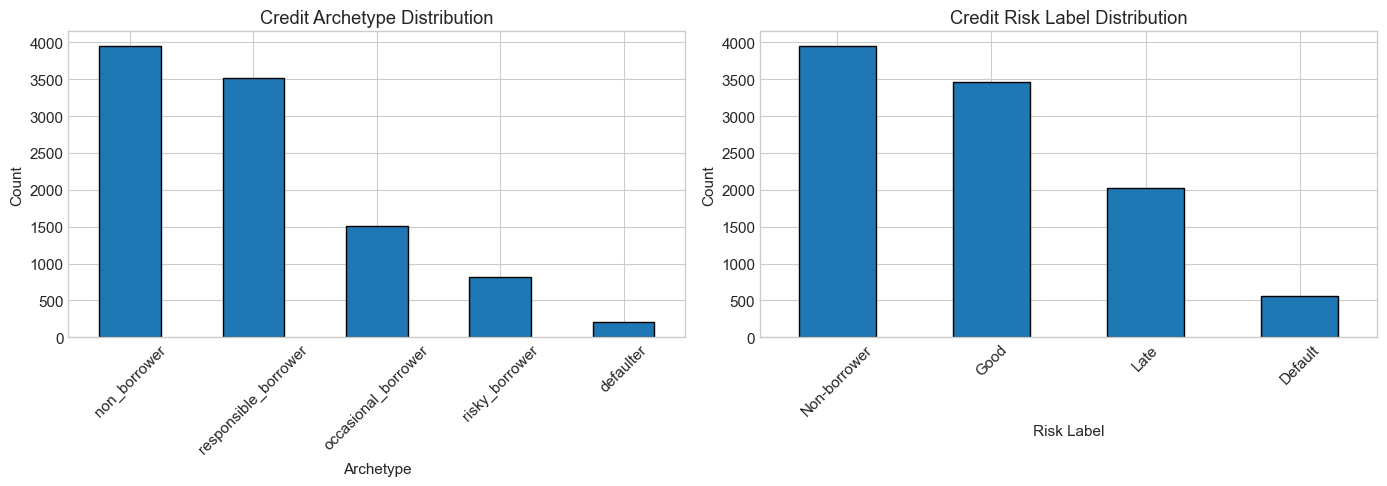

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_extended['credit_archetype'].value_counts().plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Credit Archetype Distribution')
axes[0].set_xlabel('Archetype')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

labels = {-1: 'Non-borrower', 0: 'Good', 1: 'Late', 2: 'Default'}
summary_extended['credit_risk_label'].map(labels).value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Credit Risk Label Distribution')
axes[1].set_xlabel('Risk Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/credit_archetype_risk.png', dpi=100, bbox_inches='tight')
plt.show()

## Temporal Distribution

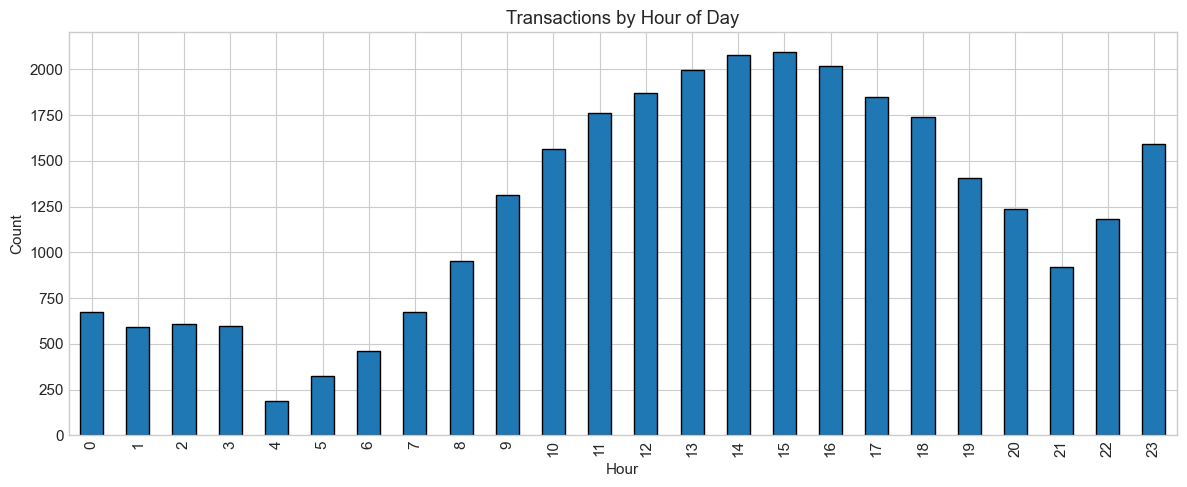

In [18]:
transactions['hour'] = pd.to_numeric(transactions['hour'], errors='coerce')
fig, ax = plt.subplots(figsize=(12, 5))
transactions['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Transactions by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figures/hour_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:
weekend_counts = transactions['is_weekend'].value_counts()
print("Weekend vs Weekday:")
for val, cnt in weekend_counts.items():
    label = "Weekend" if val == True else "Weekday"
    print(f"  {label}: {cnt} ({cnt/len(transactions)*100:.1f}%)")

Weekend vs Weekday:
  Weekday: 20762 (69.9%)
  Weekend: 8949 (30.1%)


## Fraud Distribution

In [20]:
fraud_counts = transactions['is_fraud'].value_counts()
print("Fraud Distribution:")
for val, cnt in fraud_counts.items():
    label = "Fraud" if val == 1 else "Legitimate"
    print(f"  {label}: {cnt} ({cnt/len(transactions)*100:.1f}%)")

print("\nFraud Types:")
fraud_types = transactions[transactions['is_fraud'] == 1]['fraud_type'].value_counts()
for ft, cnt in fraud_types.items():
    print(f"  {ft}: {cnt} ({cnt/fraud_counts[1]*100:.1f}%)")

Fraud Distribution:
  Legitimate: 29711 (100.0%)

Fraud Types:


## Key Correlations

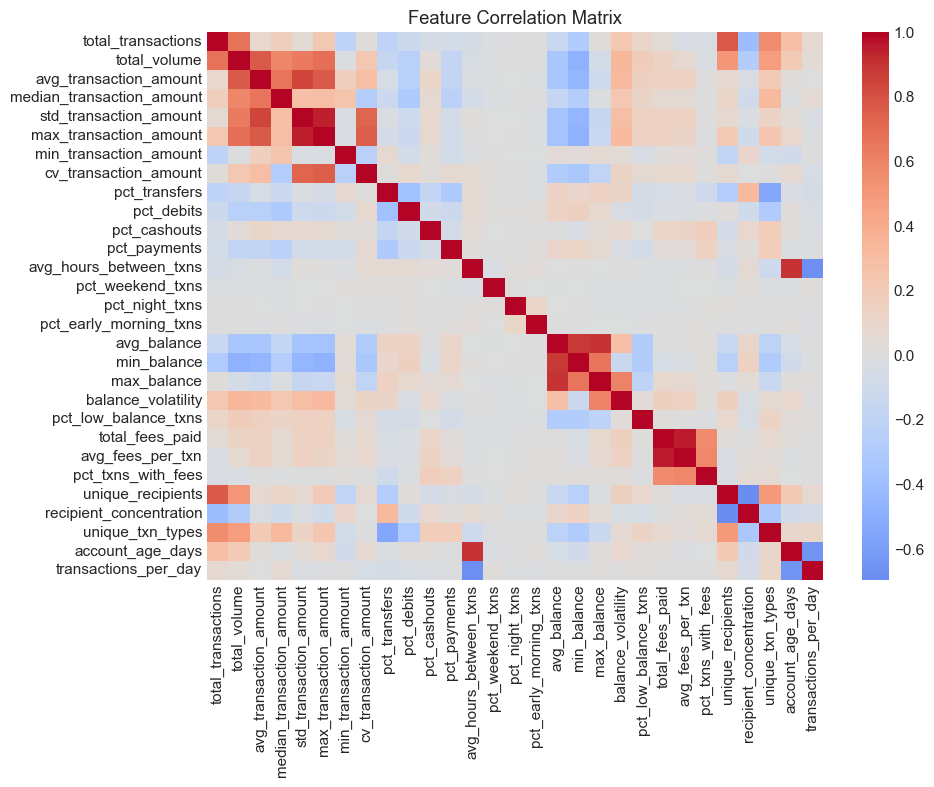

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
num_features = features.select_dtypes(include=[np.number])
corr = num_features.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary Statistics Table

In [23]:
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Users',
        'Total Transactions',
        'Avg Transactions per User',
        'Unique Transaction Types',
        'Avg Transaction Amount (GHS)',
        'Std Transaction Amount (GHS)',
        'Min Transaction (GHS)',
        'Max Transaction (GHS)',
        'Non-borrowers (%)',
        'Responsible Borrowers (%)',
        'Risky Borrowers (%)',
        'Default Rate (%)'
    ],
    'Value': [
        len(summary_extended),
        len(transactions),
        len(transactions) / len(summary_extended),
        transactions['TRANS. TYPE'].nunique(),
        transactions['AMOUNT'].mean(),
        transactions['AMOUNT'].std(),
        transactions['AMOUNT'].min(),
        transactions['AMOUNT'].max(),
        (summary_extended['credit_risk_label'] == -1).sum() / len(summary_extended) * 100,
        (summary_extended['credit_archetype'] == 'responsible_borrower').sum() / len(summary_extended) * 100,
        (summary_extended['credit_archetype'] == 'risky_borrower').sum() / len(summary_extended) * 100,
        (summary_extended['credit_risk_label'] == 2).sum() / len(summary_extended) * 100
    ]
})
summary_stats

,Metric,Value
0,Total Users,1.000000e+04
1,Total Transactions,2.971100e+04
2,Avg Transactions per User,2.971100e+00
3,Unique Transaction Types,6.000000e+00
4,Avg Transaction Amount (GHS),2.967168e+01
5,Std Transaction Amount (GHS),3.975165e+01
6,Min Transaction (GHS),1.776357e-15
7,Max Transaction (GHS),6.363700e+02
8,Non-borrowers (%),3.951000e+01
9,Responsible Borrowers (%),3.511000e+01
